SCENARIO 1 – CLUSTERING USING K-MEANS

Task 1: Import Required Libraries

In [8]:
print("Akhilon S - 24BAD008")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

Akhilon S - 24BAD008


Task 2: Load Dataset

In [9]:
print("Akhilon S - 24BAD008")
data = pd.read_csv("C:\ML_Lab\Mall_Customers.csv")
print(data.head())

Akhilon S - 24BAD008
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


Task 3: Data Preprocessing

In [10]:
print("Akhilon S - 24BAD008")
# Check missing values
print(data.isnull().sum())

# Scaling
scaler = StandardScaler()
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
X_scaled = scaler.fit_transform(X)

Akhilon S - 24BAD008
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Task 4: Select Relevant Features

In [11]:
print("Akhilon S - 24BAD008")
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

Akhilon S - 24BAD008


Task 5: Elbow Method (Find Optimal K)

Akhilon S - 24BAD008


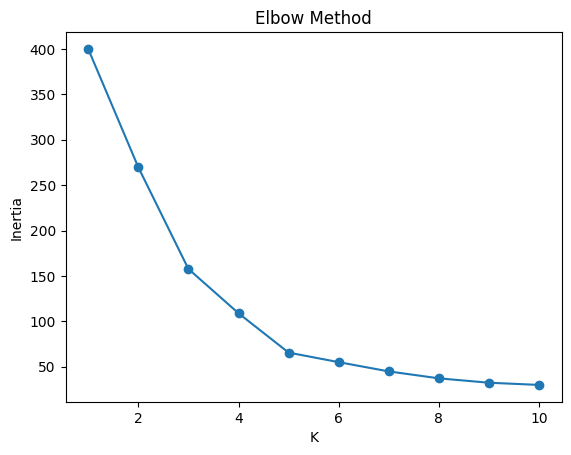

In [12]:
print("Akhilon S - 24BAD008")
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

Task 6: Apply K-Means

In [13]:
print("Akhilon S - 24BAD008")
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

Akhilon S - 24BAD008


Task 7: Assign Cluster Labels

In [14]:
print("Akhilon S - 24BAD008")
data['Cluster'] = y_kmeans
print(data.head())

Akhilon S - 24BAD008
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


TTask 8: Visualize Clusters

Akhilon S - 24BAD008


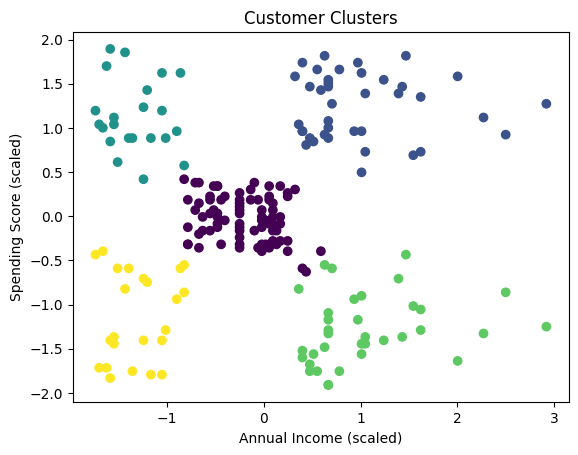

In [15]:
print("Akhilon S - 24BAD008")
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.title('Customer Clusters')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

Task 9: Interpret Cluster Characteristics

In [16]:
print("Akhilon S - 24BAD008")
cluster_summary = data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_summary)

Akhilon S - 24BAD008
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


Evaluation Metrics

In [17]:
print("Akhilon S - 24BAD008")
sil_score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", sil_score)

Akhilon S - 24BAD008
Silhouette Score: 0.5546571631111091


Cluster Centroids Visualization

Akhilon S - 24BAD008


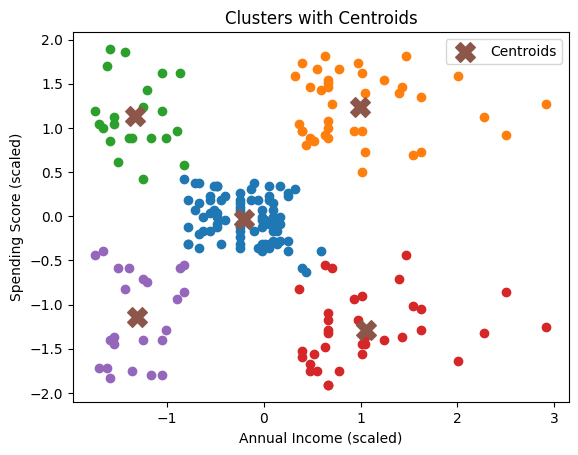

In [18]:
print("Akhilon S - 24BAD008")
plt.figure()

for i in range(5):
    plt.scatter(X_scaled[y_kmeans == i, 0],
                X_scaled[y_kmeans == i, 1])

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0],
            centroids[:, 1],
            s=200,
            marker='X',
            label='Centroids')

plt.title('Clusters with Centroids')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()

plt.show()

Scenario - 2

Task 1: Load Dataset

In [19]:
print("Akhilon S - 24BAD008")
data = pd.read_csv("Mall_Customers.csv")
print(data.head())

Akhilon S - 24BAD008
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


Task 2: Preprocessing and Scaling

In [20]:
print("Akhilon S - 24BAD008")

# Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Akhilon S - 24BAD008


Task 3: Apply Gaussian Mixture Model (GMM)

In [21]:
print("Akhilon S - 24BAD008")
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)

Akhilon S - 24BAD008


Task 4: Choose Number of Components

Akhilon S - 24BAD008


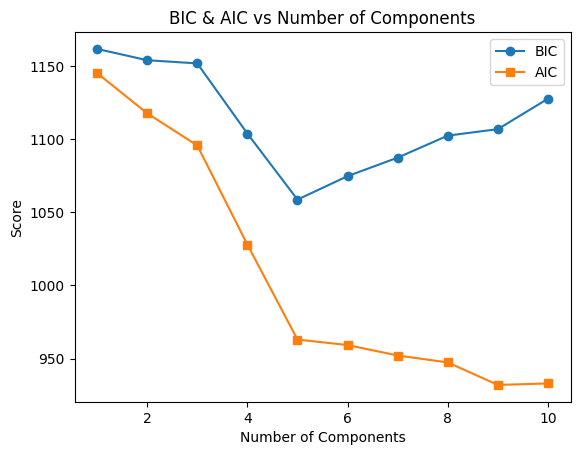

In [22]:
print("Akhilon S - 24BAD008")

import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

bic_scores = []
aic_scores = []
k_range = range(1, 11)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

# Plot both curves
plt.plot(k_range, bic_scores, marker='o', label='BIC')
plt.plot(k_range, aic_scores, marker='s', label='AIC')

plt.title('BIC & AIC vs Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.legend()
plt.show() 

Task 5: Fit Model (EM Algorithm)

In [23]:
print("Akhilon S - 24BAD008")
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

Akhilon S - 24BAD008


,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


Task 6: Predict Cluster Probabilities

In [24]:
print("Akhilon S - 24BAD008")
probabilities = gmm.predict_proba(X_scaled)
print(probabilities[:5])

Akhilon S - 24BAD008
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


Task 7: Assign Clusters

In [25]:
print("Akhilon S - 24BAD008")
labels = gmm.predict(X_scaled)
data['GMM_Cluster'] = labels
print(data.head())

Akhilon S - 24BAD008
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   GMM_Cluster  
0            4  
1            2  
2            4  
3            2  
4            4  


Task 8: Compare with K-Means

In [26]:
print("Akhilon S - 24BAD008")
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

data['KMeans_Cluster'] = kmeans_labels

Akhilon S - 24BAD008


Evaluation Metrics

In [27]:
print("Akhilon S - 24BAD008")
from sklearn.metrics import silhouette_score

print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score (GMM):", silhouette_score(X_scaled, labels))

Akhilon S - 24BAD008
Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score (GMM): 0.5536892843811245


Visualization 1: Cluster Scatter (GMM)

Akhilon S - 24BAD008


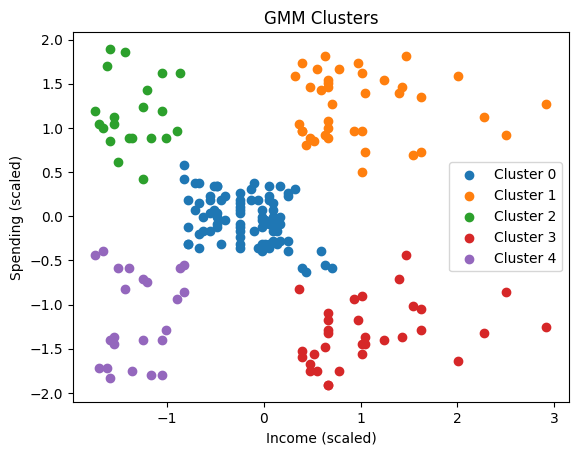

In [28]:
print("Akhilon S - 24BAD008")
plt.figure()

for i in range(5):
    plt.scatter(X_scaled[labels == i, 0],
                X_scaled[labels == i, 1],
                label=f'Cluster {i}')

plt.title('GMM Clusters')
plt.xlabel('Income (scaled)')
plt.ylabel('Spending (scaled)')
plt.legend()
plt.show()

Visualization 2: Cluster Probability Distribution

Akhilon S - 24BAD008


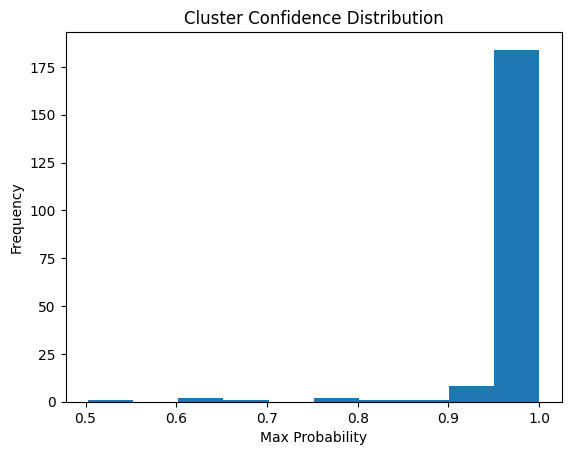

In [29]:
print("Akhilon S - 24BAD008")
plt.figure()
plt.hist(probabilities.max(axis=1), bins=10)
plt.title('Cluster Confidence Distribution')
plt.xlabel('Max Probability')
plt.ylabel('Frequency')
plt.show()

Visualization 3: K-Means vs GMM Comparison

Akhilon S - 24BAD008


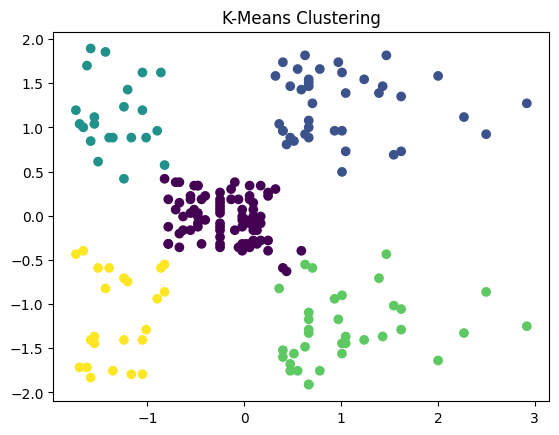

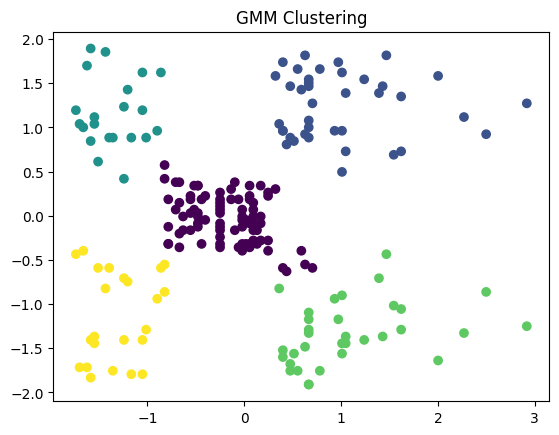

In [30]:
print("Akhilon S - 24BAD008")
plt.figure()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title('K-Means Clustering')
plt.show()

plt.figure()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title('GMM Clustering')
plt.show()

GMM Contour Plot

Akhilon S - 24BAD008


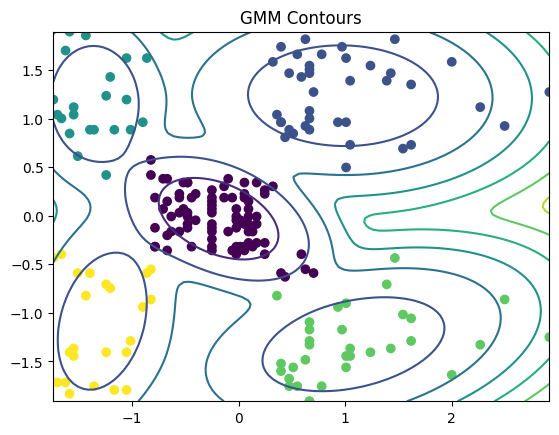

In [31]:
print("Akhilon S - 24BAD008")
import numpy as np

x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)

grid = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.title("GMM Contours")
plt.show()